In [32]:
import MAS_library as MASL
import numpy as np
import scipy
import h5py as h5
import matplotlib.pyplot as plt
import readgadget
from collections import defaultdict
from mpi4py import MPI
import random

class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self, boxsize):
        self.comm = MPI.COMM_WORLD
        self.boxsize = boxsize;
        return

    def nested_dict(self, n, type):
        """ Definition of nested dictionary """
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: nested_dict(n-1, type))

    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));

    def dot(self, x, y):
        """Dot product of two vectors"""
        return sum(x_i*y_i for x_i, y_i in zip(x, y));

    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;

    def statistics(self, x):
        """Given a vector it returns the average and std of the list! """
        return (np.average(x),np.std(x));

    def halo_selection(self, data_address, string, mass_limit, extra_columns=False):
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z] and additional columns of[Rvir,M200b] of halo population if requested!
        """
        data = np.loadtxt(data_address);
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            if extra_columns:
                halo_pop = np.zeros((np.shape(data[condition])[0],8))
            else:
                halo_pop = np.zeros((np.shape(data[condition])[0],6))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[:,5] # R_vir
                halo_pop[:,7] = data[:,20] # Mass
        elif (string == "-"):
            condition = data[:,20]<= mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[:,5] # R_vir
                halo_pop[:,7] = data[:,20] # Mass
        else:
            for i in range(6):
                halo_pop[:,i] = data[:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[:,5] # R_vir
                halo_pop[:,7] = data[:,20] # Mass
        return halo_pop;

    def alpha_list(self, vel, velocity_bulk):
        """computing alpha for halos/particle using the bulk velocity. The output is an array containing velocities."""
        alpha = np.zeros((np.shape(vel)[0]));
        for i in range(np.shape(vel)[0]):
            alpha[i] = dot(vel[i,:], velocity_bulk)/norm(velocity_bulk)
        return alpha;

    def vels_in_cell(self, ngrid, pos, vel, sub_box_index):
        boxsize = self.boxsize;
        """outputting the velocity of halos in the give sub-box """
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_halos =vel[condition_tot];
        # pos_halos =pos[condition_tot]# For test you can output pos[vel_halos, pos_halos];
        return vel_halos

    def velocity_bulk(self, ngrid, pos,vel, sub_box_index):
        boxsize = self.boxsize;
        """computing the bulk velocity in a sub-box using the velocities of objects"""
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
        sigma_vel_grids= np.array([np.std(vel[condition_tot,0]),np.std(vel[condition_tot,1]),np.std(vel[condition_tot,2])])
        return [vel_grids,sigma_vel_grids];


    def catalogue_header(self, address, column=-1):
        """Takes the address of the halo catalogue and reads the whole header by default. If the column is specified then just prints the corresponding column!"""
        f = open(address)
        header = f.readline()
        header_list = header.split(' ') #list of columns
        if column==-1:
            for i in range(np.shape(header_list)[0]):
                print(str(i)+":"+header_list[i])
        if column!=-1:
            print(str(column)+":"+header_list[column])

    def gadget_load(self, snapshot, ptype=[1]):
        """Takes the address of the a gadget 2 snapshot and returns the pos and velocity of particles!
           input: snapshot address, ptype -- > [1] for cdm and [2] for neutrinos!
        """
        pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
        vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
        # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
        return np.array([pos,vel])


    def Random_sub_box(self, ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices!
        """
        res = np.transpose([random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number)])
        return res

    def alpha_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        boxsize = self.boxsize;
        bulk_vel = velocity_bulk(ngrid, boxsize, pos_pcl,vel_pcl, sub_box_index); # Bulk velocity using cdm/neutrino
        vels_p1 = vels_in_cell(ngrid, boxsize, pos_p1, vel_p1, sub_box_index);# velocity of population 1
        vels_p2 = vels_in_cell(ngrid, boxsize, pos_p2, vel_p2, sub_box_index); # velocity of population 2
        ## computing alpha for two populations!
        alphas_p1 = alpha_list(vels_p1, velocity_bulk);
        alphas_p2 = alpha_list(vels_p2, velocity_bulk);
        data.append(sub_box_index, np.average(alpha), np.std(alpha));
        # data containing sub-nox index, average of alpha and std of alpha!
        return data
    

    def Parallelized_alpha_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Parallelizing sub-boxes over number of CPUs and computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        comm = self.comm;
        boxsize = self.boxsize;
        rank = comm.Get_rank();
        size = comm.Get_size();
        t_start = MPI.Wtime()
        data=[]
        if rank == 0:
            a_row = sub_box_lists.shape[0]
            if a_row >= size:
                split = numpy.array_split(sub_box_lists, size, axis=0)
        else:
            split = None
        split = comm.scatter(split, root=0) # This scatters each part of vector over each CPU! The vector was initially produced based on number of CPUs.
        # split = numpy.dot(split, b)
        for i in range(np.shape(split)):
            sub_box_index = split[i];
            bulk_vel = velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index);# alpha for population 1
            vels_p2 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index); # alpha for population 2

            alphas_p1 = alpha_list(vels_p1, bulk_vel);
            alphas_p2 = alpha_list(vels_p2, bulk_vel);

            data.append(sub_box_index, np.average(alpha_p1), np.average(alpha_p2), np.std(alpha_p1), np.std(alpha_p2));
            # data containing sub-nox index, average of alpha_pi and std of alphas!

        data = comm.gather(data, root=0)
        if rank == 0:
            result = numpy.vstack(data)
            t_diff_multi = MPI.Wtime() - t_start    ### Stop stopwatch ###
            print('Time taken one core:', t_diff_one, 'Time taken one multicore:', t_diff_multi)
        return result

In [38]:
boxsize=1200.0;
sim = 'Mn_0d6_nu_pcls'; num = 3; ptype=[1]
snapshot = './../Simulations/L1200_N64//'+sim+'/output/snap00'+str(num)+'_cdm'
mass_limit = 1.e14;

obj = massive_neutrinos(boxsize);
## particles read
cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
pos_cdm = cdm_pcl[0]; 
vel_cdm = cdm_pcl[1];

### Neutrinos read:
sim = 'Mn_0d6_nu_pcls'; num = 3; ptype=[1]
snapshot = './../Simulations/L1200_N64//'+sim+'/output/snap00'+str(num)+'_ncdm0'
cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
pos_nu = cdm_pcl[0]; 
vel_nu = cdm_pcl[1];


## Halo catalogue!
sim = 'Mn_0d6'
halo_address = './../Simulations/L1200_N64/'+sim+'/output/halos/out_'+str(num)+'.list'
halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
pos_halo_p1, vel_halo_p1 = halo_p1[:,:3],halo_p1[:,3:6]
halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
pos_halo_p2, vel_halo_p2 = halo_p2[:,:3],halo_p2[:,3:6]


(array([164., 206., 188., 214., 207., 190., 174., 181., 186., 202.]),
 array([   2.11845,  121.8589 ,  241.59935,  361.3398 ,  481.08025,
         600.8207 ,  720.56115,  840.3016 ,  960.04205, 1079.7825 ,
        1199.52295]),
 <BarContainer object of 10 artists>)

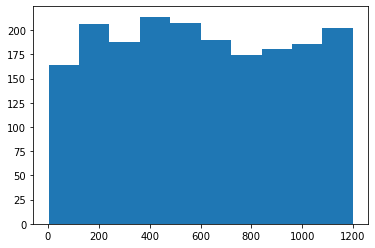

In [40]:
plt.hist(halo_p1[:,2])

In [19]:
obj.velocity_bulk(32, pos_nu, vel_nu, [0,0,0])

[array([-354.19092,  -35.93078,  106.17599], dtype=float32),
 array([292.45975, 351.41074, 332.09216], dtype=float32)]

In [20]:
obj.velocity_bulk(32, pos_cdm, vel_cdm, [0,0,0])

[array([-357.86163 ,  -55.616516,  241.9096  ], dtype=float32),
 array([125.83029,  92.1962 , 100.45397], dtype=float32)]

In [27]:
pos_halo_p1

array([[ 553.12067,  499.22305,  600.98987],
       [ 413.76566,  526.20612,  469.74673],
       [ 412.76917,  528.03699,  474.82233],
       ...,
       [1180.85864,  705.16791,  628.35443],
       [1055.56531,  671.29126,  710.26947],
       [ 712.11627, 1050.5802 ,  617.72931]])

In [42]:
obj.vels_in_cell(10, pos_cdm, vel_cdm, [0,0,0])

array([[-274.885   ,  -65.9496  ,  181.25757 ],
       [-278.95245 ,  -46.713535,  222.4191  ],
       [-326.99335 ,  -45.666504,  233.34224 ],
       ...,
       [ 188.2175  , -158.6575  ,  369.103   ],
       [-129.36037 , -362.77017 ,   22.497211],
       [  42.92021 , -142.60486 , -355.01492 ]], dtype=float32)

In [46]:
pos_halo_p1

array([[ 553.12067,  499.22305,  600.98987],
       [ 413.76566,  526.20612,  469.74673],
       [ 412.76917,  528.03699,  474.82233],
       ...,
       [1106.3512 , 1063.22192,  824.08203],
       [1055.56531,  671.29126,  710.26947],
       [ 712.11627, 1050.5802 ,  617.72931]])

In [54]:
obj.vels_in_cell(10, pos_halo_p1, vel_halo_p1, [1,1,1])

array([[ -19.06,  277.71,  420.2 ],
       [ 282.89, -286.63, -108.92],
       [ 161.31, -149.86, -299.19],
       [  69.14, -115.84,  -88.37],
       [ -74.  ,  -51.7 , -269.02]])

(array([113., 140., 126., 113., 116., 109., 118., 120., 132., 126.]),
 array([   1.42997 ,  121.261973,  241.093976,  360.925979,  480.757982,
         600.589985,  720.421988,  840.253991,  960.085994, 1079.917997,
        1199.75    ]),
 <BarContainer object of 10 artists>)

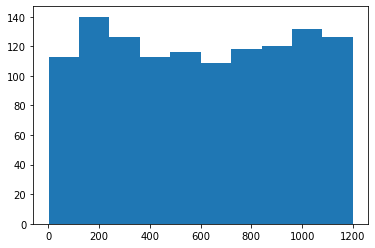

In [50]:
plt.hist(halo_p2[:,2])

In [71]:
def halo_selection(data_address, string, mass_limit):
    """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
        input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
        output: A new catalogue with [x,y,z,v_x,v_y,v_z,Rvir,M200b] of halo population
    """
    data = np.loadtxt(data_address);
    if (string == "+"):
        condition = data[:,20]> mass_limit;
        halo_pop = np.zeros((np.shape(data[condition])[0],8))
        for i in range(6):
            halo_pop[:,i] = data[condition][:,8+i]
        halo_pop[:,6] = data[condition][:,5] # R_vir
        halo_pop[:,7] = data[condition][:,20] # Mass
    elif (string == "-"):
        condition = data[:,20]<= mass_limit;
        halo_pop = np.zeros((np.shape(data[condition])[0],8))
        for i in range(6):
            halo_pop[:,i] = data[condition][:,8+i]
        halo_pop[:,6] = data[condition][:,5] # R_vir
        halo_pop[:,7] = data[condition][:,20] # Mass
    else:
        for i in range(6):
            halo_pop[:,i] = data[:,8+i]
        halo_pop[:,6] = data[:,5] # R_vir
        halo_pop[:,7] = data[:,20] # Mass
    return halo_pop;

In [74]:
halo_address = './../Simulations/L1200_N64/Mn_0d6//output/halos/out_3.list'
halo_pop1 = halo_selection(halo_address, '+', mass_limit)

In [ ]:
# To run: mpiexec  --oversubscribe -n 16 python MPI_examples.py

class Massive_Neutrinos:
    """
    MPI examples in Python
    """
    def __init__(self):
        self.comm = MPI.COMM_WORLD
        return

In [10]:
def velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index):
    """computing the bulk velocity in a sub-box using the velocities of objects"""
    condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
    condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
    condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
    condition_tot = (condition_x) & (condition_y) & (condition_z)
    vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
    sigma_vel_grids= np.array([np.std(vel[condition_tot,0]),np.std(vel[condition_tot,1]),np.std(vel[condition_tot,2])])
    # For test:
    pos = pos[condition_tot];
    
    return [pos,sigma_vel_grids]; #/norm(vel_grids);


num=3
for sim in ['Mn_0d6']:
    snapshot = './../Simulations/L1200_N64/'+sim+'/output/snap00'+str(num)+'_cdm'
    # halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
    ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
    pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
    vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s


In [31]:
boxsize=1024.;
a = velocity_bulk(4, boxsize, pos_cdm,vel_cdm, [0,3,3])

(array([15711., 15594., 16330., 17674., 16548., 16832., 15777., 16017.,
        16677., 16694.]),
 array([ 768.0027 ,  793.60223,  819.2017 ,  844.8013 ,  870.4008 ,
         896.00037,  921.59985,  947.1994 ,  972.79895,  998.39844,
        1023.998  ], dtype=float32),
 <BarContainer object of 10 artists>)

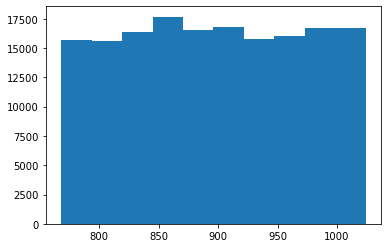

In [33]:
x = np.arange(np.shape(a[0])[0])
plt.hist(a[0][:,1])

In [29]:
np.shape(a[0])

(1293511, 3)

# Functions

In [19]:

def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
data = nested_dict(9, list)

def norm(x):
    """norm of a vector"""
    return np.sqrt(sum(x_i*x_i for x_i in x));

def dot(x, y):
    """Dot product of two vectors"""
    return sum(x_i*y_i for x_i, y_i in zip(x, y));

def velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index):
    """computing the bulk velocity in a sub-box using the velocities of objects"""
    condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
    condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
    condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
    condition_tot = (condition_x) & (condition_y) & (condition_z)
    vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
    return vel_grids; #/norm(vel_grids);

def alpha_list(vel, velocity_bulk):
    """computing alpha for halos/particle using the bulk velocity. The output is an array containing velocities."""
    alpha = np.zeros((np.shape(vel)[0]));
    for i in range(np.shape(vel)[0]):
        alpha[i] = dot(vel[i,:], velocity_bulk)/norm(velocity_bulk)
    return alpha;

def halo_selection(data_address, string, mass_limit): # Todo: Produce both halo catalogues together to save memory!
    """computing the halo population obtained by a mass limit and whether we want larger or smaller halos. The output is 
    [x,y,z,v_x,v_y,v_z,Rvir,M200b]"""
    data = np.loadtxt(data_address);
    if (string == "+"):
        condition = data[:,20]> mass_limit;
        halo_pop = np.zeros((np.shape(data[condition])[0],8))
        for i in range(6):
            halo_pop[:,i] = data[condition][:,8+i]
        halo_pop[:,6] = data[condition][:,5] # R_vir
        halo_pop[:,7] = data[condition][:,20] # Mass
    if (string == "-"):
        condition = data[:,20]<= mass_limit;
        halo_pop = np.zeros((np.shape(data[condition])[0],8))
        for i in range(6):
            halo_pop[:,i] = data[condition][:,8+i]
        halo_pop[:,6] = data[condition][:,5] # R_vir
        halo_pop[:,7] = data[condition][:,20] # Mass
    return halo_pop;

def halos_in_cell_vel(ngrid, boxsize, pos,vel, sub_box_index): 
    """outputting the velocity of halos in the give sub-box """
    condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
    condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
    condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
    condition_tot = (condition_x) & (condition_y) & (condition_z)
    vel_halos =vel[condition_tot];
    # pos_halos =pos[condition_tot]
    return vel_halos # For test you can output pos[vel_halos, pos_halos];

def halo_header(address, column=-1):
    """Takes the address of the halo and reads the header by default. If the column is specified then just prints the corresponding column!"""
    f = open(address)
    header = f.readline()
    header_list = header.split(' ') #list of columns
    # print(header_list)
    if column==-1:
        for i in range(np.shape(header_list)[0]):
            print(str(i)+":"+header_list[i])
    if column!=-1:
        print(str(column)+":"+header_list[column])

        
def halo_load(address): # Todo: keep only certain columns! Also rewrite halo_population
    """Takes the address of the halo and load the file!"""
    data= np.loadtxt(address)
    return data;

def cdm_gadget_load(snapshot, ptype=[1]):
    """Takes the address of the CDM gadget 2 snapshot and returns the pos and velocity of particles!"""
    pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
    vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
    # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
    return np.array([pos,vel])



# Loading data

In [51]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls1 = []

        for sim in ['Mn_0d6']:
            
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls1.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:Mn_0d6, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [52]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls2 = []
        for sim in ['lcdm']:
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls2.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:lcdm, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [18]:
import random
ngrid= 100;
a = np.transpose([random.sample(range(1, 100), 3),random.sample(range(1, 100), 3),random.sample(range(1, 100), 3)])




In [19]:
np.shape(a)

(3, 3)

In [20]:
a

array([[43, 45, 53],
       [35, 48, 54],
       [68, 30, 32]])

In [14]:
a[1]

[11, 15, 49]

<ipython-input-56-b7bca3e510e7>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


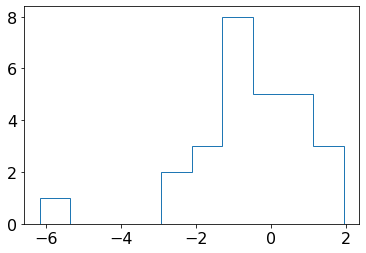

In [56]:

counts, bins = np.histogram(np.array(data_ls2)-np.array(data_ls1), bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

<ipython-input-32-129abb71fb07>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


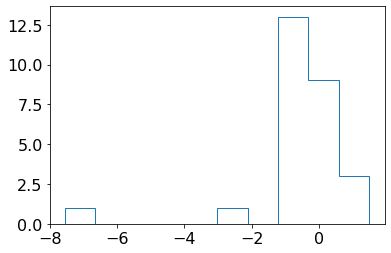

In [32]:

counts, bins = np.histogram(data_ls, bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

# $\alpha$ histogram for a given $N_{grid}$

<ipython-input-22-6d078357fcce>:20: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


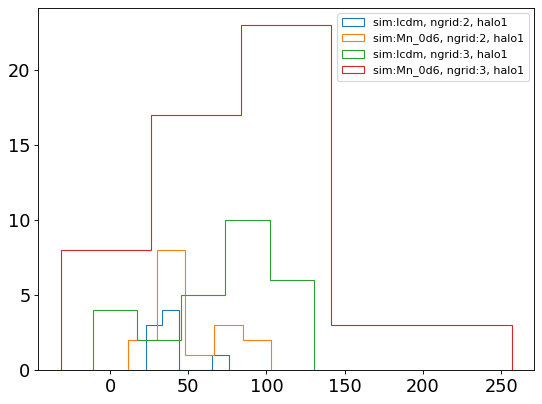

In [22]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)

for ngrid in [2,3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="n"
    alpha_all_h1=[]
    alpha_all_h2=[]
    for num in [3]: # the snapshot number start from high redshift
        for sim in ['lcdm', 'Mn_0d6']:
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

            counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
            plt.legend()
            ######
            # counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            # plt.stairs(counts, bins, alpha=0.1, hatch='.',fill=True, label="sim:"+sim+", ngrid:"+str(ngrid)+", halo2")
            plt.legend()
# plt.

## $\alpha$ for different $N_{grids}$

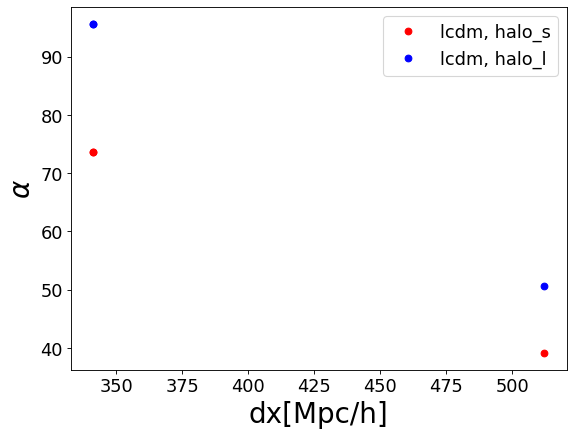

In [24]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)
# for sim in ['lcdm', 'Mn_0d6']:
for sim in ['lcdm']:

    for ngrid in [2,3]:
        boxsize=1024.;
        mass_limit = 1.e14;
        verbose="n"
        alpha_all_h1=[]
        alpha_all_h2=[]
        for num in [3]: # the snapshot number start from high redshift
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

                        
        x1 = [boxsize/ngrid] 
        y1 = [np.average(alpha_all_h1)]
        # print(arr)
        plt.plot(x1,y1,"ro")  
        
        x = [boxsize/ngrid] 
        y = [np.average(alpha_all_h2)]
        plt.plot(x,y,"bo")
            # plt.plot(boxsize/ngrid, np.average(alpha_all_h2), label="sim:"+sim+", halo12)        
    plt.plot(x1,y1,"ro", label=sim+", halo_s")
    plt.plot(x,y,"bo", label=sim+", halo_l")
    
plt.rcParams['xtick.labelsize']=16
plt.rcParams['ytick.labelsize']=16
plt.xlabel("dx[Mpc/h]",fontsize=25)
plt.ylabel(r"$\alpha$",fontsize=25)
plt.legend(fontsize=16)
# plt.

In [14]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm
# cmap = cm.get_cmap("jet",lut=6)

# v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index)
# x = np.arange(0, grid, 1)*boxsize/grid
# y = np.arange(0, grid, 1)*boxsize/grid
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

NameError: name 'grid' is not defined

<Figure size 960x800 with 0 Axes>

## Plot

In [306]:
# # 
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm



# # cmap = cm.get_cmap("jet",lut=6)
# cmap = cm.get_cmap("jet")
# # cmap.set_under("w")

# ####
# x = np.arange(0, grid, 1)*1024./grid
# y = np.arange(0, grid, 1)*1024./grid
# z_s=10
# vmax = 0.05 ;vmin=-0.06
# plot = plt.pcolormesh(x, y, delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_n[:,:,z_s], cmap='gray')
# # plt.clabel(cset, inline=False)
# plt.title("phase-")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_g[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("Gaussian")
# plt.colorbar(plot)

In [133]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s]+delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+ + phase-")
# plt.colorbar(plot)

## Power spectra

In [305]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # compute power spectrum
# Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# k       = Pk_p.k3D
# Pk0_p     = Pk_p.Pk[:,0] #monopole
# Pk0_n     = Pk_n.Pk[:,0] #monopole
# Pk0_g     = Pk_g.Pk[:,0] #monopole

# plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


In [304]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # # compute power spectrum
# # Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# # Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# # k       = Pk_p.k3D
# # Pk0_p     = Pk_p.Pk[:,0] #monopole
# # Pk0_n     = Pk_n.Pk[:,0] #monopole
# # Pk0_g     = Pk_g.Pk[:,0] #monopole

# # plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# # plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# # plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# # plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# # dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


Text(0, 0.5, '$P[Mpc^3/h^3]$')

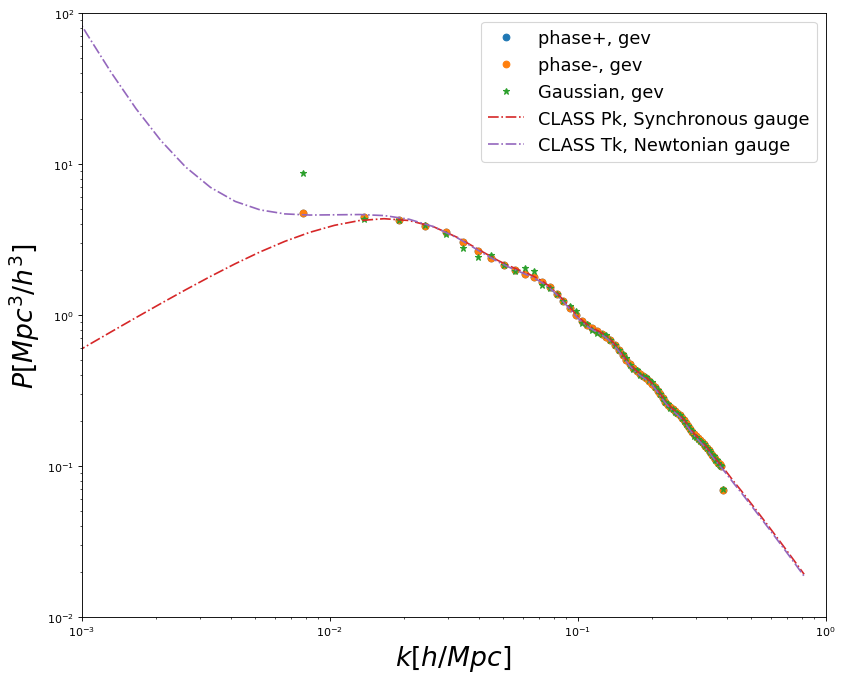

In [212]:
# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
    
# data = nested_dict(4, list)

    # read header
    # header   = readgadget.header(snapshot)
    # BoxSize  = header.boxsize/1e3  #Mpc/h
    # Nall     = header.nall         #Total number of particles
    # Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
    # Omega_m  = header.omega_m      #value of Omega_m
    # Omega_l  = header.omega_l      #value of Omega_l
    # h        = header.hubble       #value of h
    # redshift = header.redshift     #redshift of the snapshot
    # Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
    # read positions, velocities and IDs of the particles

In [2]:
import numpy as np
class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self):
        # self.comm = MPI.COMM_WORLD
        return
    
    def nested_dict(self, n, type):
        """ Definition of nested dictionary """
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: nested_dict(n-1, type))
        
    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));

    def dot(self, x, y):
        """Dot product of two vectors"""
        return sum(x_i*y_i for x_i, y_i in zip(x, y));
    
    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;
    
    def halo_selection(self, data, string, mass_limit): 
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z,Rvir,M200b] of halo population
        """
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        if (string == "-"):
            condition = data[:,20]<= mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        return halo_pop;


In [7]:
obj = massive_neutrinos();
x = [0,0,0]
y = [3,3,3]
obj.dist(x,y)

5.196152422706632

In [16]:
x = [0,0,0]
y = [1,1,1]

In [13]:
x[:]-y[:]

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [17]:
np.subtract(x,y)

array([-1, -1, -1])

In [4]:
import random

import numpy as np

In [2]:
a = [1,2,3,4,5]
np.average(a)

3.0

In [3]:
np.std(a)

1.4142135623730951

In [2]:
 def Random_sub_box(ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices! 
        """
        res = np.transpose([random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number)])
        return res

In [6]:
a = Random_sub_box(4, 3)

In [11]:
a

array([[1, 3, 0],
       [2, 1, 3],
       [0, 2, 1]])

In [10]:
for i,j,k in a:
    print(i,j,k)

1 3 0
2 1 3
0 2 1
